## From model to production

We're going to use a computer vision example to look at the end-to-end process of creating a deep learning application. More specifically, we're going to build a bear classifier! In the process, we'll discuss the capabilities and constraints of deep learning, explore how to create datasets, look at possible gotchas when using deep learning in practice, and more

## The practice of Deep Learning

When implementing deep learning in practical applications, it's crucial to set realisti expectations rather than viewing it as a magical solution.

Our approach to these models involves two primary considerations:

- **Constraints**: These arise from various factors, including the quality and volume of available data, computational resources, the inherent complexity of the problem, and real-world ethical or security concerns
*(ex. A model trained only on daytime photos will not be able to "see" at night.)*

- **Capabilities**: This refers to a model's ability to discern intricate patterns from limited data, automate repetitive actions and apply learned knowledge to make predictions on unseen data.
*(ex. Recognizing a disease from an X-ray better than an inexperienced eye or finding hidden correlations between chemical variables in a wine.)*

The best thing to do is to keep an open mind. If you remain open to the possibility that deep learning might solve part of your problem with less data or complexity than you expect, then it is possible to design a process where you can find the specific capabilities and constraints related to your particular problem as you work through the process.



## Starting your project

When selecting a project, the most important consideration is data availability. The goal is not to find the perfect dataset or project, but just to get started and iterate from there.

It is recommended to iterate from end to end in your project, meaning that you should first complete every step as well as you can in a reasonable amount of time, all the way to the end. For instance, if your final goal is an application that runs on a mobile phone, then that should be what you have after each iteration.

When you are just starting out with deep learning, it's not a good idea to branch out into very different areas, to places that deep learning has not been applied to before. That's because if your model doesn't work at first, you will not know whether it is because you have made a mistake, or if the very problem you are trying to solve is simply not solvable with deep learning.

So, it is best at first to start with something where you can find an example online.

In [36]:
from fastai.vision.all import *

from fastbook import *

from fastai.vision.widgets import *

path = "/home/davidebui/DeepLearning/Lesson2/Bear_dataset"
bear_types = 'grizzly','teddy','polar','black', 'panda'

bears = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(224)
)

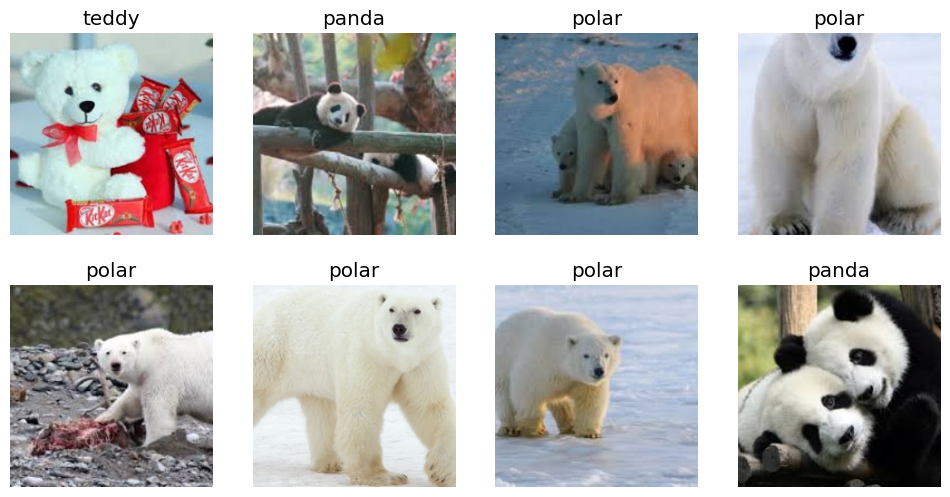

In [37]:
dls = bears.dataloaders(path)
dls.show_batch(max_n = 8)

In [38]:

failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[]

By default **Resize** crops the images to fit a square shape of the size requested, using the full width or height. This can result in losing some important details. Alternatively, you can ask fastai to pad the images with zeros(black), or squish/stretch them:

- **ResizeMethod.Squish/Stretch**: if you _Squish_ or _Stretch_ the images they end up as unrealistic shapes, leading to a model that learns that things look different to how they actually are, which you wuold expect to result in lower accuracy.

- **ResizeMethod.Pad, pad_mode = 'zeros'**: if we _pad_ the images then we have a whole lot of empty space, which is just wasted computation for our model and results in a lower effectiver resolution for the part of the image we actually use.

What we normally do in practice is to randomly select part of the image, and crop to just that part. On each epoch (which is one complete pass through all of our images in the dataset) we randomly select a different part of each image. This means that our model can learn to focus on, and recognize, different features in our images

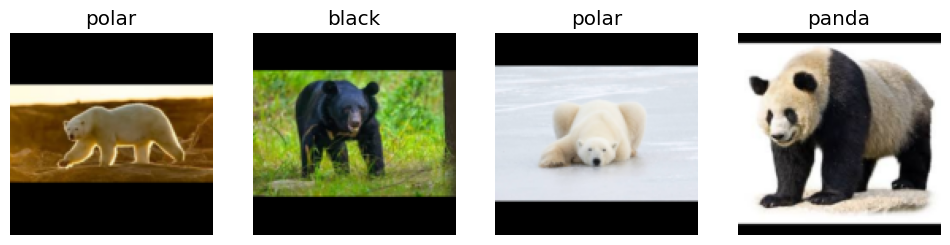

In [ ]:
# hide
ex_bears = bears.new(item_tfms = Resize(128, ResizeMethod.Pad, pad_mode = 'zeros'))
ex_dls = ex_bears.dataloaders(path)
ex_dls.valid.show_batch(max_n = 4, nrows = 1)

In [39]:
learn = vision_learner(dls, resnet18, metrics = error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.161373,0.684261,0.262295,00:30


epoch,train_loss,valid_loss,error_rate,time
0,0.936605,0.266739,0.065574,00:43
1,0.641061,0.079008,0.032787,00:40
2,0.453888,0.068083,0.032787,00:39
3,0.350227,0.065201,0.032787,00:38


Now let's see whether the mistakes the model is making are mainly thinking that grizzlies are teddies or that grizzlies are black bears, or something else. To visualize this, we can create a ***confusion matrix***:

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

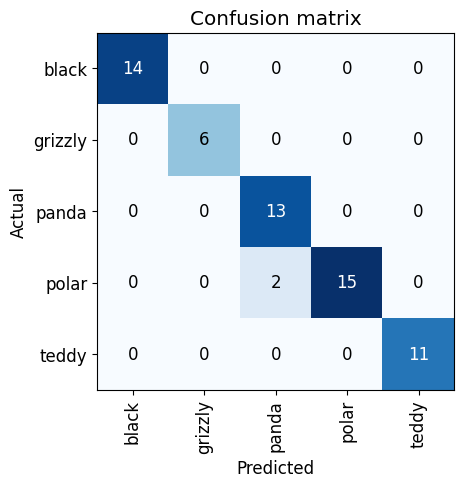

In [40]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

The rows represent all the categories in our dataset, respectively. The columns represent the images which the model predicted as black, grizzly, panda, polar and teddy bears, respectively. Therefore, the _diagonal of the matrix_ shows the images which were classified correctly, and teh off diagonals cells represent those whiche were classified incorrectly.

The goal is to have white everywhere except the diagonal, whre we want dark blue.

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

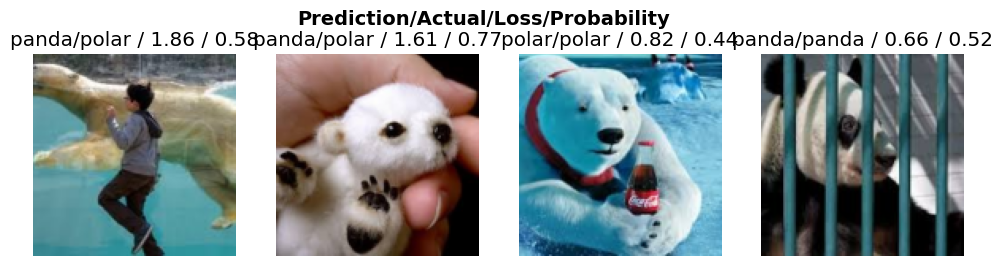

In [28]:
interp.plot_top_losses(4, nrows = 1)

This output shows that the image with the highest loss are the ones that has been predicted as "panda" and "grizzly" with high confidence. However, it's labeled as "polar" and "black".
_(grizzly and black are not shown in the output above)_

This intuitive approach to doing data cleaning is to do it _before_ you train a model. But as you have seen, in this case, a model can actually help you find data issues more quickly and easily. So, we normally prefer to train a quick and simple model first, and then use it to help us with data cleaning.

fastai includes a handy GUI for data cleaning called ***ImageClassifierCleaner*** that allows you to choose a category and the training versus validation set and view the highest-loss images (in order), along with menus to allow images to be selected for removal or relabeling

In [ ]:
cleaner = ImageClassifierCleaner(learn)
cleaner

We can see that amongst our "grizzly" is an image that contains two bears: one grizzly, one black. So, we should choose **<Delete>** in teh menu under this image. ***ImageClassifierCleaner*** doesn't actually do the deleting or changing of the labels for you; it just returns the indices of items to change. So, for instance, to delete (Unlink) all images selected for deletion, we would run:

In [30]:
# hide
for idx in cleaner.delete():
    cleaner.fns[idx].unlink()

To move images for which we've selected a different category, we would run:

In [31]:
# hide
for idx, cat in cleaner.change():
    shutil.move(str(cleaner.fns[idx]),path/cat)

The widget **cleaner** has trace each image that we decide to move:

- **idx**: it's the index of the image on the list of files

- **cat**: it's the new category(destination folder) that you choose from the menu of the widget

The **shutil.move(str(cleaner.fns[idx]), path/cat)** function is the action of moving files:

- **cleaner.fns[idx]**: return the current path of the correct image using its index

- **str(...)**: transform the path into a string(because shutil.move prefers to work with strings instead of paths)

- **path/cat**: defines the destination. Take the main path (path) and adds the name of the new category(cat), pointing the sub directory correctly (ex. from /bears/grizzly to /bears/black)

We'll be seeing more examples of model-driven data cleaning throught this book. Once we've cleaned up our data, we can retrain our model. Try it yourself, and see if your accuracy improves!

Since the model still have issues in recognize which bear is a polar or a bear, I'll try to load the dataset with a new argument called **batch_tfms** with function **aug_transforms()**.
This function create different versions of the images(rotated, zoomed or with different brightness), helping the model to not be fooled by the white color on the background.

I could have trained the model with more epochs, but doing so would risk ***overfitting***, which is when the model learns by heart and ends up recognizing only specific pixels in photos it hase already seen instead of learning what a panda or a polar bear actually is 

In [48]:
bears2 = DataBlock(
    blocks = [ImageBlock, CategoryBlock],
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(224, ResizeMethod.Squish),
    batch_tfms = aug_transforms()
)


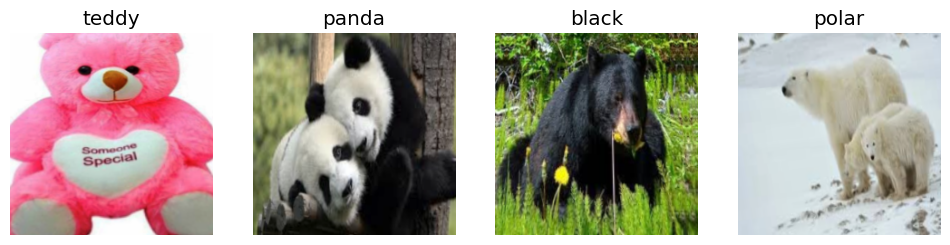

In [50]:
dls2 = bears2.dataloaders(path)
dls2.show_batch(max_n = 4, nrows = 1)

In [52]:
learn2 = vision_learner(dls2, resnet18, metrics = error_rate)
learn2.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.865903,1.219475,0.475410,00:36


epoch,train_loss,valid_loss,error_rate,time
0,1.120508,0.313948,0.114754,00:44
1,0.744876,0.074919,0.032787,00:51
2,0.535597,0.063629,0.032787,00:51
3,0.410490,0.068136,0.032787,00:47


In [ ]:
interp2 = ClassificationInterpretation.from_learner(learn2)
interp2.plot_confusion_matrix()

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

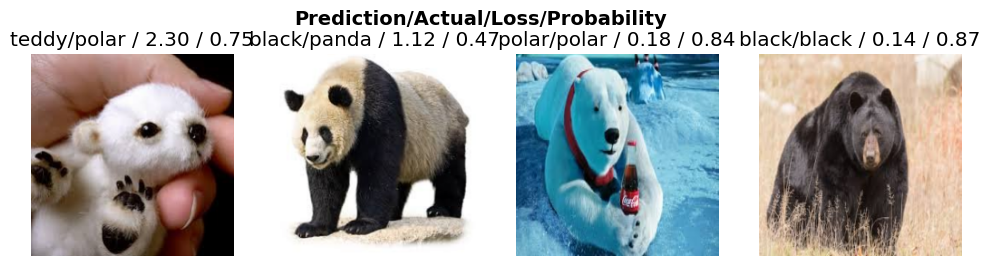

In [58]:
interp2.plot_top_losses(4, nrows = 1)

Now I can see which images are the false positives. So now we can retrieve the path of each false positives and clean them to have a perfect model that recognize each bear


In [ ]:
losses, idxs = interp2.top_losses(2)

for i, idx in enumerate(idxs):
    file_path = dls2.valid_ds.items[idx]
    file_path.unlink()
    print(f"Top {i+1} loss: {file_path}")


Top 1 loss: /home/davidebui/DeepLearning/Lesson2/Bear_dataset/data/polar/polar_bear99.jpg
Top 2 loss: /home/davidebui/DeepLearning/Lesson2/Bear_dataset/data/panda/panda43.jpg


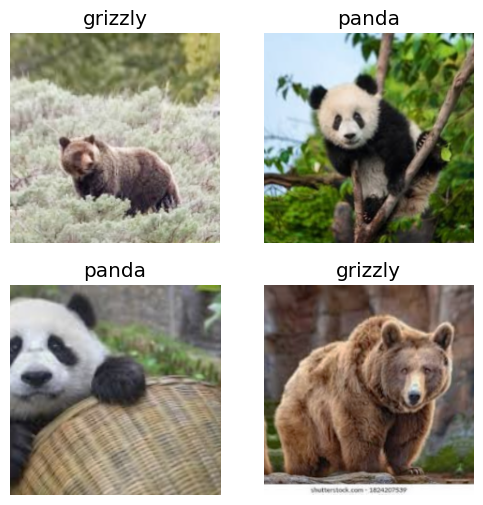

In [75]:
final_dls = DataBlock(
    blocks = [ImageBlock, CategoryBlock],
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(224),
    batch_tfms = aug_transforms()
).dataloaders(path)

final_dls.show_batch(max_n = 4)

In [ ]:
final_learner = vision_learner(final_dls, resnet18, metrics = error_rate)
final_learner.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time


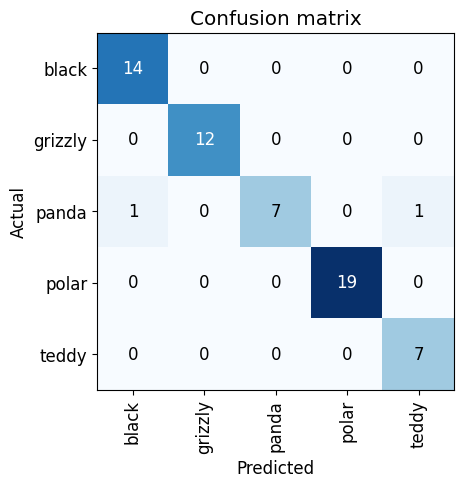

In [73]:
final_interp = ClassificationInterpretation.from_learner(final_learner)
final_interp.plot_confusion_matrix()

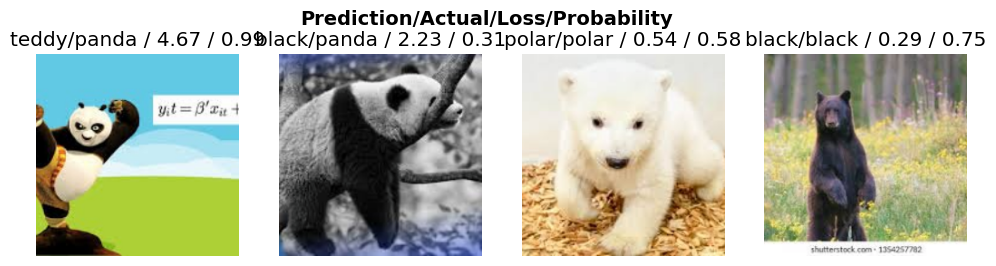

In [74]:
final_interp.plot_top_losses(4, nrows = 1)